# 4. Data Preprocessing

In [ ]:
# 1. Feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = df.drop('status', axis=1)
X_scaled = scaler.fit_transform(X)

df_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=df.index)
df_scaled['status'] = df['status']

# assign df_scaled back to df
df=df_scaled
df.head()

,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,nb_eq,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,-0.436327,-0.193964,-0.421020,0.379116,-0.477984,-0.142915,-0.387464,-0.197604,0.0,-0.293683,...,-1.860473,1.129194,-0.28037,-0.549299,-1.307594,-0.429340,6.978227,0.934264,0.320974,0
1,0.287067,0.177207,2.375182,-1.081136,-0.477984,-0.142915,-0.387464,-0.197604,0.0,-0.293683,...,0.537498,-0.885587,-0.28037,-0.510022,0.548471,-0.429340,-0.143303,0.934264,-0.467407,1
2,1.173224,2.682613,2.375182,1.109242,0.001174,-0.142915,2.356473,2.237556,0.0,2.711505,...,0.537498,-0.885587,-0.28037,-0.587348,-0.018839,2.491612,-0.143303,0.934264,-1.255788,1
3,-0.779940,-0.936306,-0.421020,-0.351010,-0.477984,-0.142915,-0.387464,-0.197604,0.0,-0.293683,...,0.537498,-0.885587,-0.28037,-0.528433,-1.307594,-0.375359,-0.143303,-1.070361,-0.073217,0
4,-0.110800,-0.565135,-0.421020,-0.351010,0.480332,-0.142915,-0.387464,-0.197604,0.0,-0.293683,...,-1.860473,1.129194,-0.28037,-0.329595,1.323334,-0.424968,-0.143303,-1.070361,1.109355,0


In [ ]:
# 2. Feature selection

from sklearn.ensemble import RandomForestClassifier

# Fit Random Forest Classifier to training data
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

feature_importances = rf_model.feature_importances_

importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print(importance_df)

                 Feature  Importance
85          google_index    0.165390
86             page_rank    0.104115
56         nb_hyperlinks    0.081922
83           web_traffic    0.079373
20                nb_www    0.042660
..                   ...         ...
61  ratio_intRedirection    0.000000
68          submit_email    0.000000
63       ratio_intErrors    0.000000
59  ratio_nullHyperlinks    0.000000
71                   sfh    0.000000

[87 rows x 2 columns]


In [ ]:
importance_threshold = 0.02

# Get the names of features below the threshold
features_to_drop = importance_df[importance_df['Importance'] < importance_threshold]['Feature'].tolist()

# drop the least important features
df = df.drop(columns=features_to_drop)
df.head()

,nb_www,ratio_digits_url,longest_word_path,phish_hints,nb_hyperlinks,ratio_intHyperlinks,ratio_extHyperlinks,ratio_extRedirection,safe_anchor,domain_age,web_traffic,google_index,page_rank,status
0,1.098907,-0.594651,-0.197666,-0.388973,-0.420926,-0.194034,0.605943,2.687711,-0.948614,-1.307594,-0.429340,0.934264,0.320974,0
1,-0.893559,1.876053,0.929003,-0.388973,-0.342965,0.967464,-0.760717,-0.596511,1.610785,0.548471,-0.429340,0.934264,-0.467407,1
2,-0.893559,1.092856,0.279002,-0.388973,-0.498886,1.056008,-0.864902,-0.596511,1.610785,-0.018839,2.491612,0.934264,-1.255788,1
3,-0.893559,-0.594651,-0.457666,-0.388973,0.370674,0.984697,-0.780995,0.341838,0.651011,-1.307594,-0.375359,-1.070361,-0.073217,0
4,1.098907,-0.594651,0.019001,-0.388973,0.088816,-0.350289,0.789798,1.419202,-0.948614,1.323334,-0.424968,-1.070361,1.109355,0


In [ ]:
print("Shape of df after feature selection:",df.shape)

Shape of df after feature selection: (11430, 14)


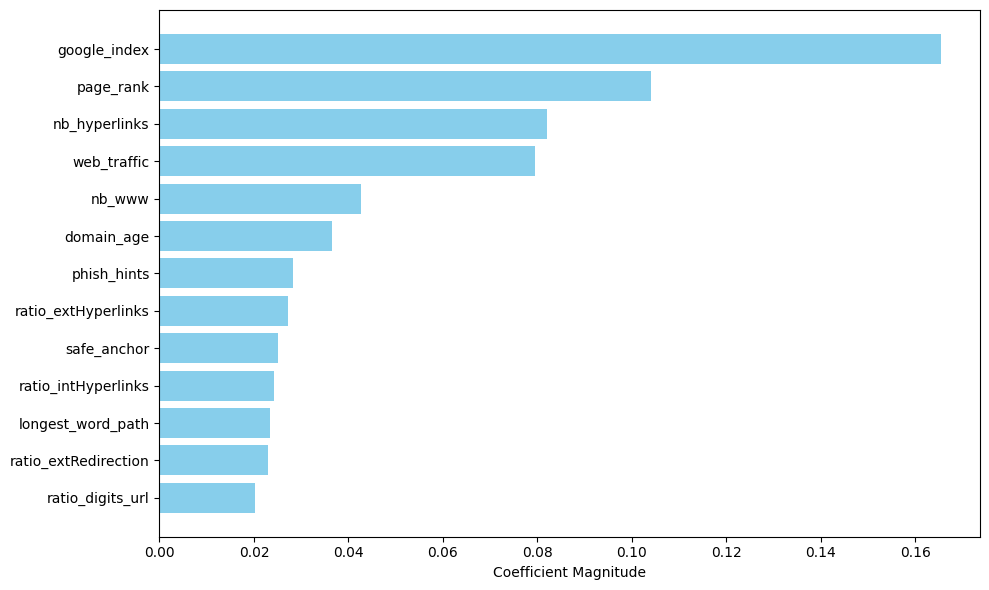

In [ ]:
# Plot the top 13 important features
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'][:13], importance_df['Importance'][:13], color='skyblue')
plt.xlabel('Coefficient Magnitude')
plt.gca().invert_yaxis()  # Highest importance at the top
plt.tight_layout()
plt.show()

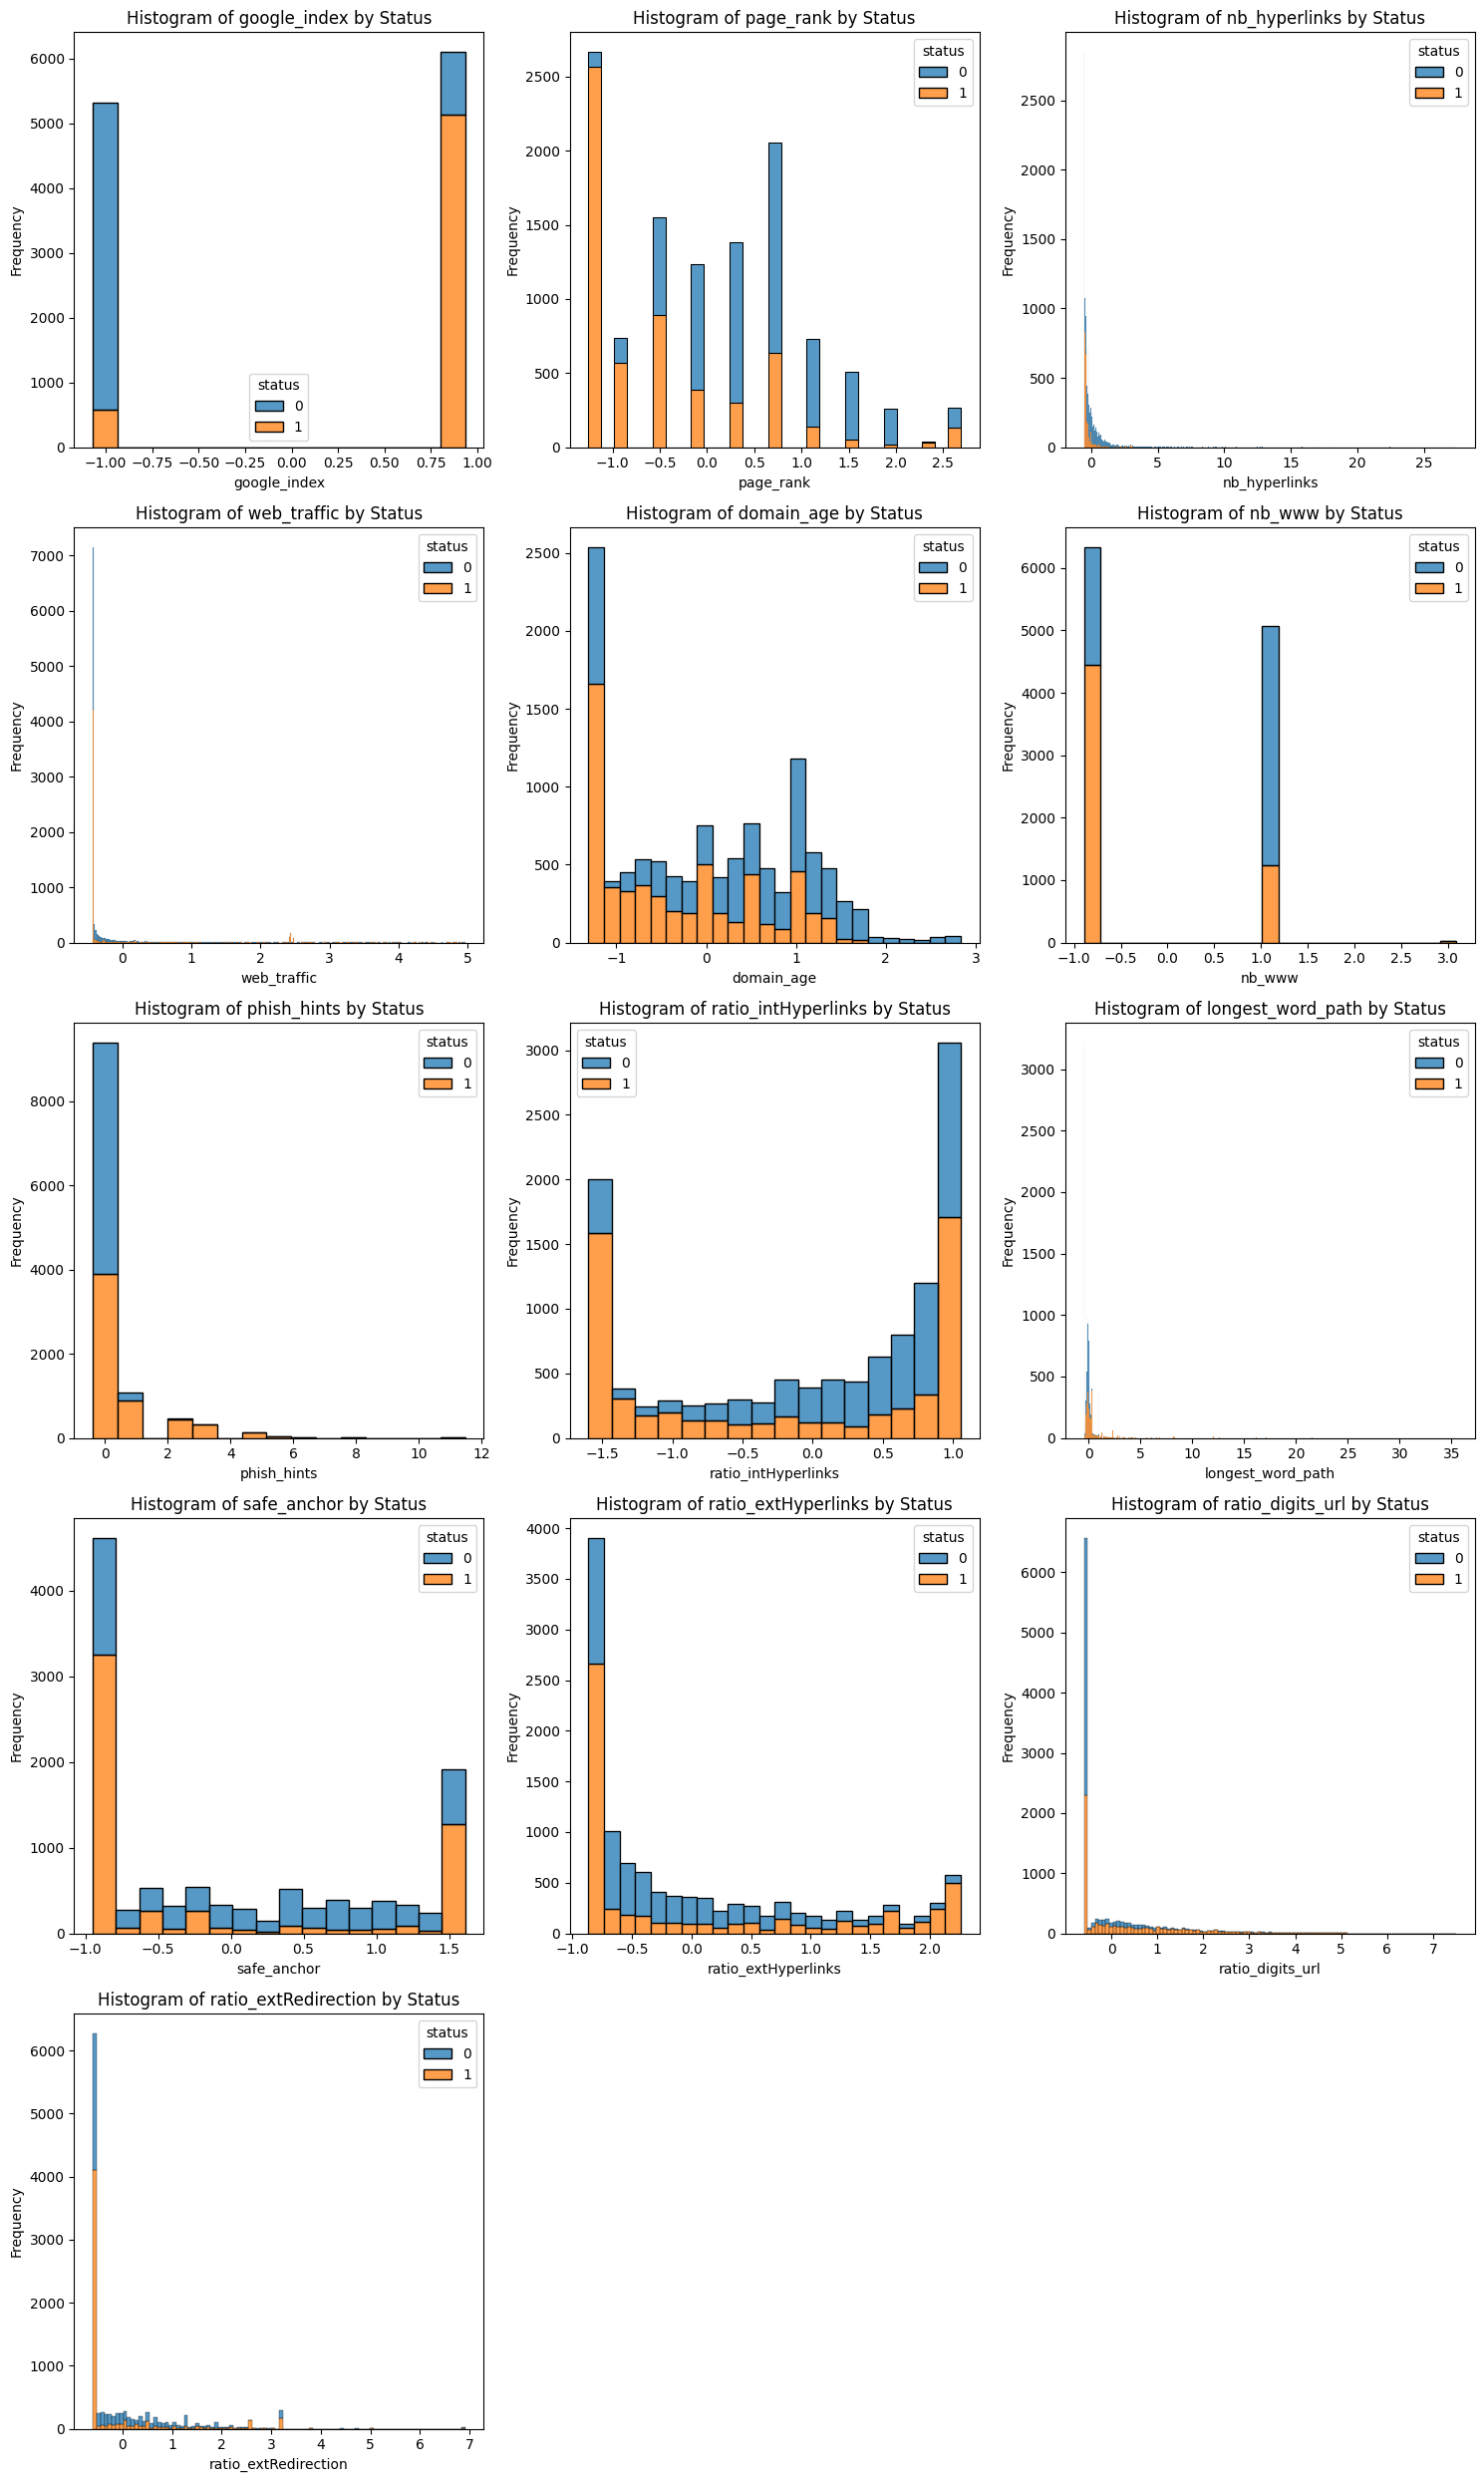

In [ ]:
# plotting features after selection
feature_importances = rf_model.feature_importances_
importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

top_features = importance_df['Feature'][:13]

num_features = len(top_features)
num_cols = 3
num_rows = (num_features + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, num_rows * 5))

for i, feature in enumerate(top_features):
    row = i // num_cols
    col = i % num_cols
    ax = axes[row, col]

    sns.histplot(data=df, x=feature, hue='status', multiple="stack", ax=ax)
    ax.set_title(f'Histogram of {feature} by Status')
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')

for i in range(num_features, num_rows * num_cols):
    row = i // num_cols
    col = i % num_cols
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

Interperetation:

google_index after scaling has the highest/ mpst significant impact in predicting phishing, sites not indexed by google may be suspicious

Other features like page_rank, nb_hyperlinks, web_traffic, etc also contribute to classification

In [ ]:
# 3. Feature engineering

# a. interaction features
df['page_rank_x_web_traffic'] = df['page_rank'] * df['web_traffic'] # Interaction between page rank and web traffic

# b. polynomial features:
df['google_index_squared'] = df['google_index'] ** 2 # Squaring the google_index feature

# c. Combining features:
df['hyperlinks_ratio'] = df['nb_hyperlinks'] / (df['nb_www'] + 1)  # Ratio of hyperlinks to www occurences (avoiding division by zero)


X = df.drop('status', axis=1)
y = df['status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
df.head()

,nb_www,ratio_digits_url,longest_word_path,phish_hints,nb_hyperlinks,ratio_intHyperlinks,ratio_extHyperlinks,ratio_extRedirection,safe_anchor,domain_age,web_traffic,google_index,page_rank,status,page_rank_x_web_traffic,google_index_squared,hyperlinks_ratio
0,1.098907,-0.594651,-0.197666,-0.388973,-0.420926,-0.194034,0.605943,2.687711,-0.948614,-1.307594,-0.429340,0.934264,0.320974,0,-0.137807,0.872849,-0.200545
1,-0.893559,1.876053,0.929003,-0.388973,-0.342965,0.967464,-0.760717,-0.596511,1.610785,0.548471,-0.429340,0.934264,-0.467407,1,0.200677,0.872849,-3.222130
2,-0.893559,1.092856,0.279002,-0.388973,-0.498886,1.056008,-0.864902,-0.596511,1.610785,-0.018839,2.491612,0.934264,-1.255788,1,-3.128937,0.872849,-4.686997
3,-0.893559,-0.594651,-0.457666,-0.388973,0.370674,0.984697,-0.780995,0.341838,0.651011,-1.307594,-0.375359,-1.070361,-0.073217,0,0.027483,1.145673,3.482452
4,1.098907,-0.594651,0.019001,-0.388973,0.088816,-0.350289,0.789798,1.419202,-0.948614,1.323334,-0.424968,-1.070361,1.109355,0,-0.471440,1.145673,0.042316


Reasoning for created features ---

Interaction Features: created by multiplying page_rank and web_traffic. This captures the combined effect of these two features. For example, a high page rank with high web traffic might be a stronger indicator of legitimacy than either feature alone.

Polynomial Features: created by squaring the google_index feature. This can help capture non-linear relationships between google_index and the target variable (status).

Combining Features: created by dividing nb_hyperlinks by nb_www (adding 1 to avoid division by zero). This represents the ratio of hyperlinks to the number of times "www" appears in the URL. A higher ratio might indicate a suspicious website.

In [ ]:
print("Shape of df after datapreprocessing:",df.shape)

Shape of df after datapreprocessing: (11430, 17)
